In [1]:
from helpers import gaussian_displacement, cat_ideal, loss_channel_kraus, apply_kraus, coherent_state
import numpy as np
import numba as na
import qutip as q
import matplotlib.pyplot as plt


In [2]:
def operator (dim, alpha):

    I = np.eye(dim)
    A = np.diag(np.sqrt(np.arange(1, dim, dtype = np.float64)), 1)
    B = A @ A
    u = B.T - I * (np.conj(alpha) ** 2) 
    v = (B   - I * (alpha ** 2))

    return u @ v 

In [3]:
def transposition(rho):
    ksi = np.trace(rho@np.transpose(rho))
    return ksi 

In [7]:
def catability_cheating(rho,op,gamma):
    ksi = np.trace(rho@np.transpose(rho))  #np.trace(rho@ op)  #gamma*np.trace(rho@np.transpose(rho)) +
    return ksi

In [13]:
#transposition
dim = 70
parity = 1
gamma = 1
alphaspace = np.arange(0.5,2.5,0.1)
alphaspace = alphaspace
np.save('results/transpose/alphaspace.npy', alphaspace)

thetaspace = np.array([0,np.pi/8,np.pi/4,np.pi/2])
np.save('results/transpose/thetaspace.npy', thetaspace)

etaspace = np.array([1,0.8])
np.save('results/transpose/etaspace.npy', etaspace)

In [14]:

for j,eta in enumerate(etaspace):
    ops = loss_channel_kraus(dim, eta)
    for i,theta in enumerate(thetaspace):
        list_trans = []
        for alpha in alphaspace:
            rho_ideal = cat_ideal(dim, alpha,theta)
            psi = apply_kraus(rho_ideal, ops)
            op = operator(dim,alpha) 
            trans = catability_cheating(psi,op,gamma)
            list_trans.append(trans)
        np.save(f'results/transpose/trans_{i}_{j}.npy', list_trans)

/home/matul/Dokumenty/Jupyter notebooks/Projekt - Noisy Cat Op/cat-env/lib64/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matul/Dokumenty/Jupyter notebooks/Projekt - Noisy Cat Op/cat-env/lib64/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


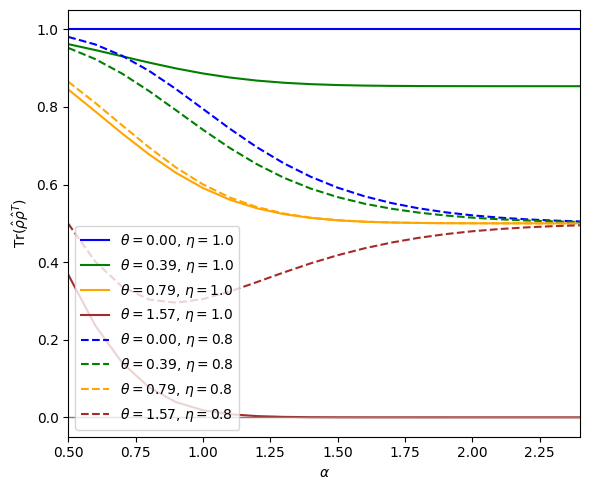

In [3]:
etaspace = np.load('results/transpose/etaspace.npy')
thetaspace  = np.load('results/transpose/thetaspace.npy')
alphaspace = np.load('results/transpose/alphaspace.npy')
fig, axes = plt.subplots( figsize = (6,5))
# alphaspace = -1j*alphaspace
line = ['blue','green','orange','brown','violet']
style = ['solid','dashed']
for j,eta in enumerate(etaspace):
    for i,theta in enumerate(thetaspace):
        trans = np.load(f'results/transpose/trans_{i}_{j}.npy')
        axes.plot(alphaspace,trans,color = line[i],linestyle = style[j],label = fr'$\theta = {theta:.2f}$, $\eta = {eta:.1f}$')

# axes.set_ylabel(r"$\mathrm{Tr}[\hat{\rho} \hat{O}_{\alpha}] + \mathrm{Tr}[\hat{\rho}  \hat{\rho}^T]$")
axes.set_ylabel(r"$\mathrm{Tr}(\hat{\rho}  \hat{\rho}^T)$")
axes.set_xlabel(r"$\alpha$")
axes.set_xlim(0.5,2.4)
# axes.set_xlim(0.5,3)
axes.axhline(y=0.0, color='gray', linestyle='-', linewidth=1)
lines1, labels1 = axes.get_legend_handles_labels()
axes.legend(loc='best')
plt.tight_layout()
plt.show()
fig.savefig('figs/transposition_2.svg')